In [108]:
import os, sys, re, random, json5
import torch
import torchvision
import torch.nn as nn
import torchvision.transforms as transforms
from Demos.BackupRead_BackupWrite import buf
from torch.utils.data import Dataset, IterableDataset, DataLoader
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image
import cv2

In [2]:
from experiments import *

In [3]:
def set_seed(seed: int):
    random.seed(seed)
    np.random.seed(seed)


set_seed(random.randint(1, 10000))


class SeedContext:
    def __enter__(self):
        self.random_state = random.getstate()
        self.numpy_state = np.random.get_state()
        set_seed(self.seed)

    def __exit__(self, *_):
        random.setstate(self.random_state)
        np.random.set_state(self.numpy_state)


__seed_context__ = SeedContext()


def seed_as(seed):
    __seed_context__.seed = seed
    return __seed_context__

In [119]:
available_categories = ('bench', 'bus', 'car', 'cat', 'dog', 'fire_hydrant', 'motorcycle', 'parking_meter',
                        'person', 'piano', 'stop_sign', 'traffic_light', 'traffic_sign', 'truck')


def load_image(
        specimen: str = 'train',
        label: str = None,
        sample: str = None,
        root: str = '..',
        log: bool = False,
        descriptor=None,
):
    try:
        if label is None: label = random.choice(available_categories)
        assert specimen in ('train', 'test', 'validation')
        assert label in available_categories
        directory = os.path.join(root, 'dataset', 'OIDv6', specimen, label)
        if sample is None: sample = random.choice(os.listdir(directory)).rsplit('.', 1)[0]
        if log: print(f'Loading {specimen}/{label}/{sample}')
        image = np.array(Image.open(os.path.join(directory, f'{sample}.jpg')))
        if descriptor is not None: return descriptor, image
        box = tuple(map(float, open(os.path.join(directory, 'labels', f'{sample}.txt')).read().rsplit(' ')[-4:]))
        return {'label': label, 'box': box, 'dir': (specimen, label, sample)}, image
    except Exception as e:
        print(f'Error loading {specimen}/{label}/{sample}')
        raise e


Descriptor = dict[str, str | tuple[float, float, float, float] | tuple[str, str, str]]


class DirDataset(Dataset):
    def __init__(self, specimen='train', root='..', hard_limit=None):
        assert specimen in ('train', 'test', 'validation')
        self.root = root
        self.directory = os.path.join(root, 'dataset', 'OIDv6', specimen)
        classes = os.listdir(self.directory)
        self.descriptors: list[Descriptor] = []
        for class_name in classes:
            class_dir = os.path.join(self.directory, class_name, 'labels')
            for sample in os.listdir(class_dir):
                box = tuple(map(float, open(os.path.join(class_dir, sample)).read().rsplit(' ')[-4:]))
                self.descriptors.append({'label': class_name, 'box': box,
                                         'dir': (specimen, class_name, sample.rsplit('.', 1)[0])})
        self.shuffle()
        if hard_limit is not None: self.descriptors = self.descriptors[:hard_limit]

    def shuffle(self):
        random.shuffle(self.descriptors)

    def __len__(self):
        return len(self.descriptors)

    def __getitem__(self, idx):
        descriptor = self.descriptors[idx]
        return load_image(*descriptor['dir'], descriptor=descriptor)

In [89]:
def plot_this(ax: plt.Axes, title=None):
    if title: ax.set_title(title)


def plot_rectangle(ax: plt.Axes, rect: tuple[float, float, float, float]):
    rect = patches.Rectangle(
        (rect[0], rect[1]),
        rect[2] - rect[0] - 1,  # -1 for inset visual
        rect[3] - rect[1] - 1,
        linewidth=2,
        edgecolor='blue',
        facecolor='none',
    )
    ax.add_patch(rect)


def plot_sample(descriptor, image, ax: plt.Axes = None):
    if ax is None: _, ax = plt.subplots(1, 1, figsize=(4, 4))
    ax.imshow(image)
    plot_rectangle(ax, descriptor['box'])
    plot_this(ax, descriptor['label'] + f' ({image.shape[1]}x{image.shape[0]})')

Loading train/fire_hydrant/251c05d9d8bcdf38


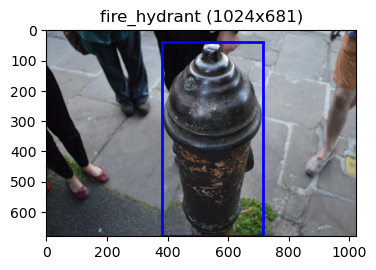

In [6]:
d, i = load_image(log=True)
plot_sample(d, i)
plt.show()

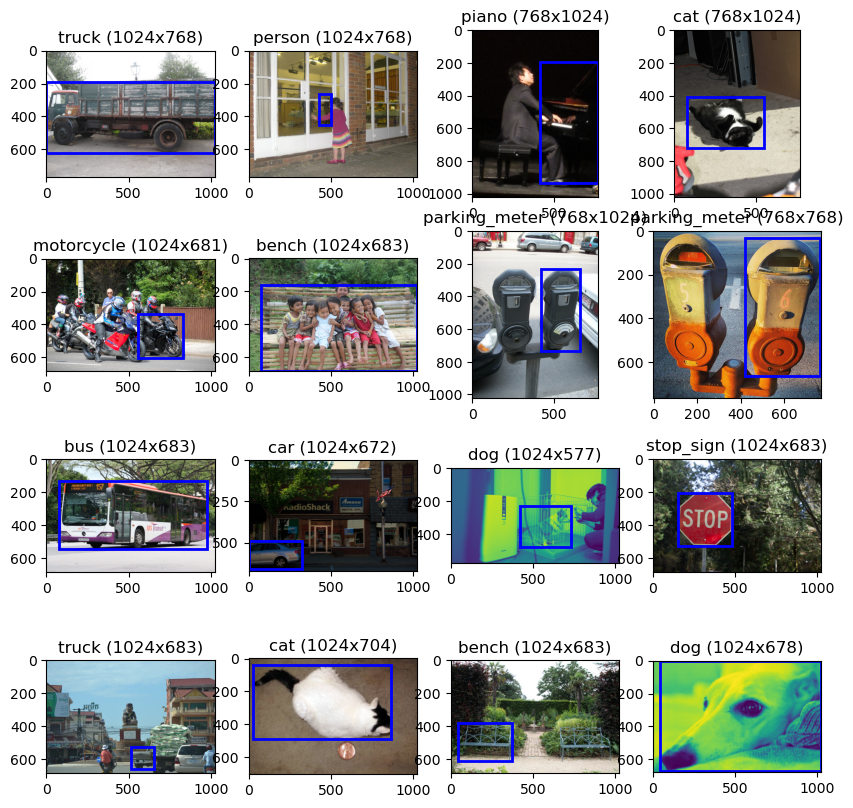

In [7]:
fig, axs = plt.subplots(4, 4, figsize=(10, 10))
for ax in axs.flatten():
    plot_sample(*load_image(), ax)
plt.show()

Loading train/traffic_sign/06937ef97333f924


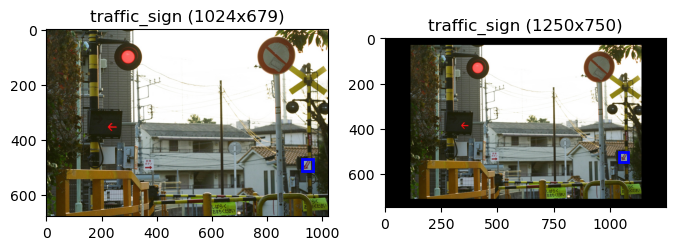

In [8]:
def pad_up_sample(descriptor, image: np.ndarray, sampling=500):
    sampling = sampling // 2
    h, w = image.shape[:2]
    hn, wn = (1 + (h - 1) // sampling) * sampling, (1 + (w - 1) // sampling) * sampling
    padded = np.zeros((hn, wn, image.shape[2]), dtype=image.dtype)
    ho, wo = (hn - h) // 2, (wn - w) // 2
    padded[ho:ho + h, wo:wo + w, :] = image
    descriptor, box = descriptor.copy(), descriptor['box']
    descriptor['box'] = (wo + box[0], ho + box[1], wo + box[2], ho + box[3])
    return descriptor, padded


_, axs = plt.subplots(1, 2, figsize=(8, 4))
d, i = load_image(log=True)
plot_sample(d, i, ax=axs[0])
plot_sample(*pad_up_sample(d, i), ax=axs[1])
plt.show()

Loading train/truck/17559ad5b6e240b8


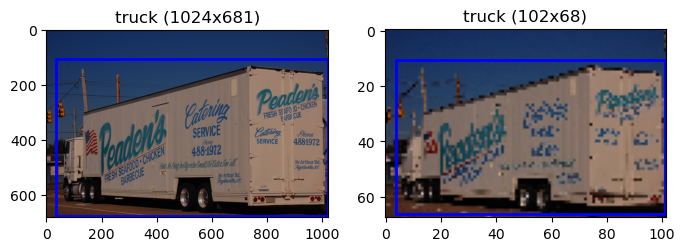

In [91]:
def rescale_sample(descriptor, image, target):
    if isinstance(target, float):
        target = (int(image.shape[0] * target), int(image.shape[1] * target))
    if isinstance(target, int):
        target = (target, int(target / image.shape[0] * image.shape[1]))
    rescaled = cv2.resize(image, dsize=target[::-1], interpolation=cv2.INTER_CUBIC)
    descriptor, box = descriptor.copy(), descriptor['box']
    descriptor['box'] = (box[0] / image.shape[1] * target[1], box[1] / image.shape[0] * target[0],
                         box[2] / image.shape[1] * target[1], box[3] / image.shape[0] * target[0])
    return descriptor, rescaled


_, axs = plt.subplots(1, 2, figsize=(8, 4))
d, i = load_image(log=True)
plot_sample(d, i, ax=axs[0])
plot_sample(*rescale_sample(d, i, 0.1), ax=axs[1])
plt.show()

Loading train/parking_meter/0b12f7cbdc590684


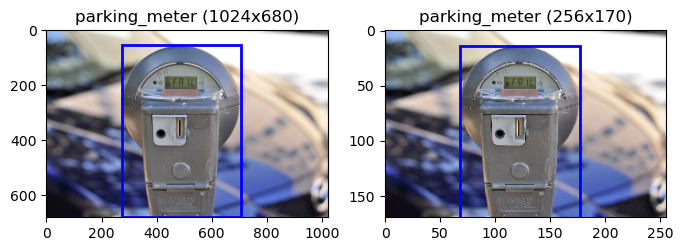

In [10]:
def ensure_within(descriptor, image, max_bounds=256):
    if image.shape[0] > image.shape[1]:
        return rescale_sample(descriptor, image, max_bounds)
    return rescale_sample(descriptor, image, int(max_bounds / image.shape[1] * image.shape[0]))


_, axs = plt.subplots(1, 2, figsize=(8, 4))
d, i = load_image(log=True)
plot_sample(d, i, ax=axs[0])
plot_sample(*ensure_within(d, i), ax=axs[1])
plt.show()

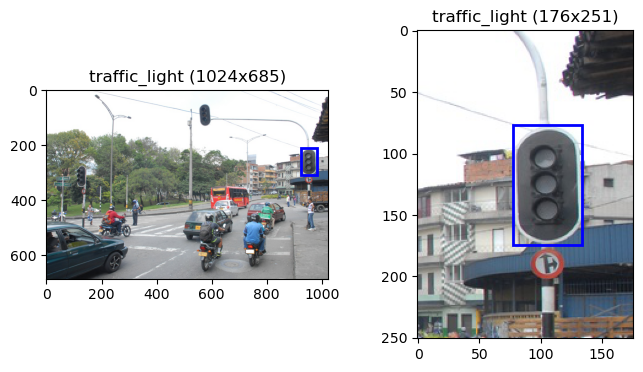

In [11]:
def context_crop_sample(descriptor, image, ratio=1.0):
    h, w = image.shape[:2]
    descriptor, box = descriptor.copy(), descriptor['box']
    major_size = (box[2] - box[0] + box[3] - box[1]) * ratio / 2
    bx1 = int(max(0, box[0] - major_size))
    bx2 = int(min(w, box[2] + major_size))
    by1 = int(max(0, box[1] - major_size))
    by2 = int(min(h, box[3] + major_size))
    cropped = image[by1:by2, bx1:bx2, :]
    descriptor['box'] = (box[0] - bx1, box[1] - by1, box[2] - bx1, box[3] - by1)
    return descriptor, cropped


_, axs = plt.subplots(1, 2, figsize=(8, 4))
d, i = load_image('train', 'traffic_light', '03b7eaf956c7d0bf')
plot_sample(d, i, ax=axs[0])
plot_sample(*context_crop_sample(d, i), ax=axs[1])
plt.show()

count 221 221


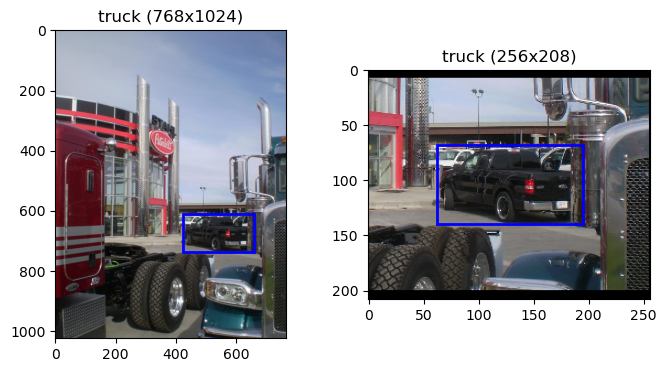

In [88]:
def split_sample(descriptor, image: np.ndarray, sampling=500):
    count = 0
    slide = sampling // 2

    h, w = image.shape[:2]
    while w >= sampling and h >= sampling:
        count += (w // slide - 1) * (h // slide - 1)
        w, h = w // 2, h // 2

    samples = np.zeros((count, 3, sampling, sampling))
    x1, y1, x2, y2 = descriptor['box']
    l_desc = []

    h, w = image.shape[:2]
    c, s = 0, 1
    while w - s * sampling + 1 > 0 and h - s * sampling + 1 > 0:
        for x in range(0, w - s * sampling + 1, s * slide):
            for y in range(0, h - s * sampling + 1, s * slide):
                samples[c] = image[y:y + s * sampling:s, x:x + s * sampling:s].transpose(2, 0, 1)
                desc = descriptor.copy()
                desc['box'] = (max(0, (x1 - x) / s), max(0, (y1 - y) / s),
                               min(sampling, (x2 - x) / s), min(sampling, (y2 - y) / s))
                # desc['box'] = (x1 + x / s, y1 + y / s, x1 + (x + s * sampling) / s, y1 + (y + s * sampling) / s)
                l_desc.append(desc)
                c += 1
        s = s * 2

    return l_desc, samples


def process_sample(descriptor, image):
    descriptor, image = context_crop_sample(descriptor, image, ratio=0.6)
    descriptor, image = ensure_within(descriptor, image, max_bounds=256)
    descriptor, image = pad_up_sample(descriptor, image, sampling=32)
    descriptors, samples = split_sample(descriptor, image, sampling=32)
    return descriptors, samples, descriptor, image


_, axs = plt.subplots(1, 2, figsize=(8, 4))
d, i = load_image('train', 'truck', '0e8a8d1dc876b6a6')
plot_sample(d, i, ax=axs[0])
ld, s, d, i = process_sample(d, i)
plot_sample(d, i, ax=axs[1])
plt.show()

In [98]:
s.shape

(221, 3, 32, 32)

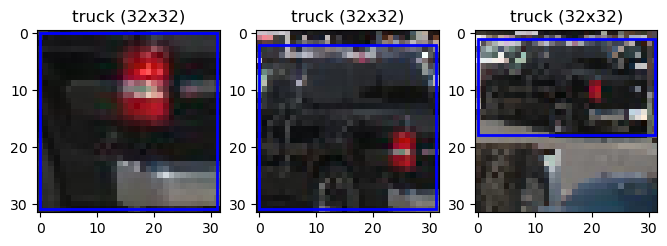

In [90]:
_, axs = plt.subplots(1, 3, figsize=(8, 4))
plot_sample(ld[102], s[102].transpose(1, 2, 0).astype(np.uint8), ax=axs[0])
plot_sample(ld[197], s[197].transpose(1, 2, 0).astype(np.uint8), ax=axs[1])
plot_sample(ld[218], s[218].transpose(1, 2, 0).astype(np.uint8), ax=axs[2])
plt.show()

In [124]:
class PipelinedDataset(IterableDataset):
    def __init__(self, dir_dataset: DirDataset, innate_batch=16, buffer_size=512):
        self.loader = DataLoader(dir_dataset)
        self.innate_batch = innate_batch
        self.buf_desc = [None] * innate_batch
        self.buf_img = np.zeros((innate_batch, 3, 32, 32), dtype=np.uint8)
        assert buffer_size % innate_batch == 0

    def flush_buffer(self):
        perm = np.random.permutation(len(self.buf_img))
        descs = [self.buf_desc[i] for i in perm]
        imgs = self.buf_img[perm]

        for st in range(0, self.buf_img.shape[0], self.innate_batch):
            yield descs[st:st + self.innate_batch], imgs[st:st + self.innate_batch]

        self.buf_img.fill(0)

    def push_buffer(self, offset, descs, imgs):
        if len(imgs) + offset > len(self.buf_img):

            fill_descs = descs[:len(self.buf_img) - offset]
            fill_imgs = imgs[:len(self.buf_img) - offset]
            next_descs = descs[len(self.buf_img) - offset:]
            next_imgs = imgs[len(self.buf_img) - offset:]

            self.buf_desc[offset:] = fill_descs
            self.buf_img[offset:] = fill_imgs
            for x in self.flush_buffer(): yield x

            return self.push_buffer(0, next_descs, next_imgs)

        self.buf_desc[offset:offset + len(descs)] = descs
        self.buf_img[offset:offset + len(imgs)] = imgs

        if offset == len(self.buf_img):
            for x in self.flush_buffer(): yield x
            return 0

        return offset + len(imgs)

    def __iter__(self):
        offset = 0
        for descriptor, image in self.loader:
            descs, imgs, _, _ = process_sample(descriptor, image)
            offset = self.push_buffer(offset, descs, imgs)


dir_dataset = DirDataset(hard_limit=10)
pipe_dataset = PipelinedDataset(dir_dataset)
loadder = DataLoader(pipe_dataset)

In [126]:
c = 0
for x in pipe_dataset.loader:
    print(len(x))
    print(x[0])
    print(x[1].shape)
    if c == 3: break
    c = c + 1

2
{'label': ['car'], 'box': [tensor([0.], dtype=torch.float64), tensor([0.6666], dtype=torch.float64), tensor([670.9942], dtype=torch.float64), tensor([1020.6669], dtype=torch.float64)], 'dir': [('train',), ('car',), ('0240ce5f9fe7f078',)]}
torch.Size([1, 1024, 683, 3])
2
{'label': ['parking_meter'], 'box': [tensor([0.6400], dtype=torch.float64), tensor([161.9197], dtype=torch.float64), tensor([606.7200], dtype=torch.float64), tensor([767.3603], dtype=torch.float64)], 'dir': [('train',), ('parking_meter',), ('533a302835d88fba',)]}
torch.Size([1, 768, 1024, 3])
2
{'label': ['cat'], 'box': [tensor([322.5600], dtype=torch.float64), tensor([112.1247], dtype=torch.float64), tensor([755.2000], dtype=torch.float64), tensor([611.2399], dtype=torch.float64)], 'dir': [('train',), ('cat',), ('00d0c59b405175a1',)]}
torch.Size([1, 683, 1024, 3])
2
{'label': ['fire_hydrant'], 'box': [tensor([225.2932], dtype=torch.float64), tensor([624.], dtype=torch.float64), tensor([370.5818], dtype=torch.float64)